# 14 · How a Clock Model Is Built — and How Well It Really Works

A granular, honest walkthrough. We build a clock model **from scratch** on three real
stocks, showing every step — the behaviour table, the regularities we find, and the
behaviour formula they lead to — then we test how well that model predicts the true turns
(the *oracle*), summarise across 100 stocks, and finally **trade it** and watch the money.

The plan:

1. **Build** the model on 3 stocks: behaviour table → regularities → behaviour formula.
   *Is it a behaviour table? a behaviour formula? a complex network?* We answer plainly.
2. **Predict** the clock vs the oracle on those 3: precision and recall.
3. **Generalise**: across 100 stocks, how good is an individual model, honestly?
4. **Trade** 3 examples: price, predicted buys/sells, and the accumulated profit.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
for _sub in ["level6", "level9", "level14", "level18"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)
import json
DATA_100 = os.path.join(ROOT, "finance", "data_100")
from finance import load_yahoo_close
def load_stock(t):
    px = load_yahoo_close(os.path.join(DATA_100, t + ".json"))
    return [px[d] for d in sorted(px)]
with open(os.path.join(ROOT, "results", "exp41_clock_prediction.json")) as _f:
    RP = json.load(_f)
STOCKS = [t for t in ["AAPL", "JPM", "XOM"] if os.path.exists(os.path.join(DATA_100, t+".json"))]
if len(STOCKS) < 3:
    STOCKS = [r["name"] for r in RP["rows"][:3]]
THETA = RP["theta"]
print("walkthrough stocks:", STOCKS, " | 100-stock summary loaded")

walkthrough stocks: ['AAPL', 'JPM', 'XOM']  | 100-stock summary loaded


## Phase 1 · Building the model

### 1.1 — The raw material: the oracle clock
Each stock's *oracle* is the set of in-hindsight perfect turns: **buy** at every trough,
**sell** at every peak. This is what a model would have to predict. Here are the three
stocks with their oracle clocks.

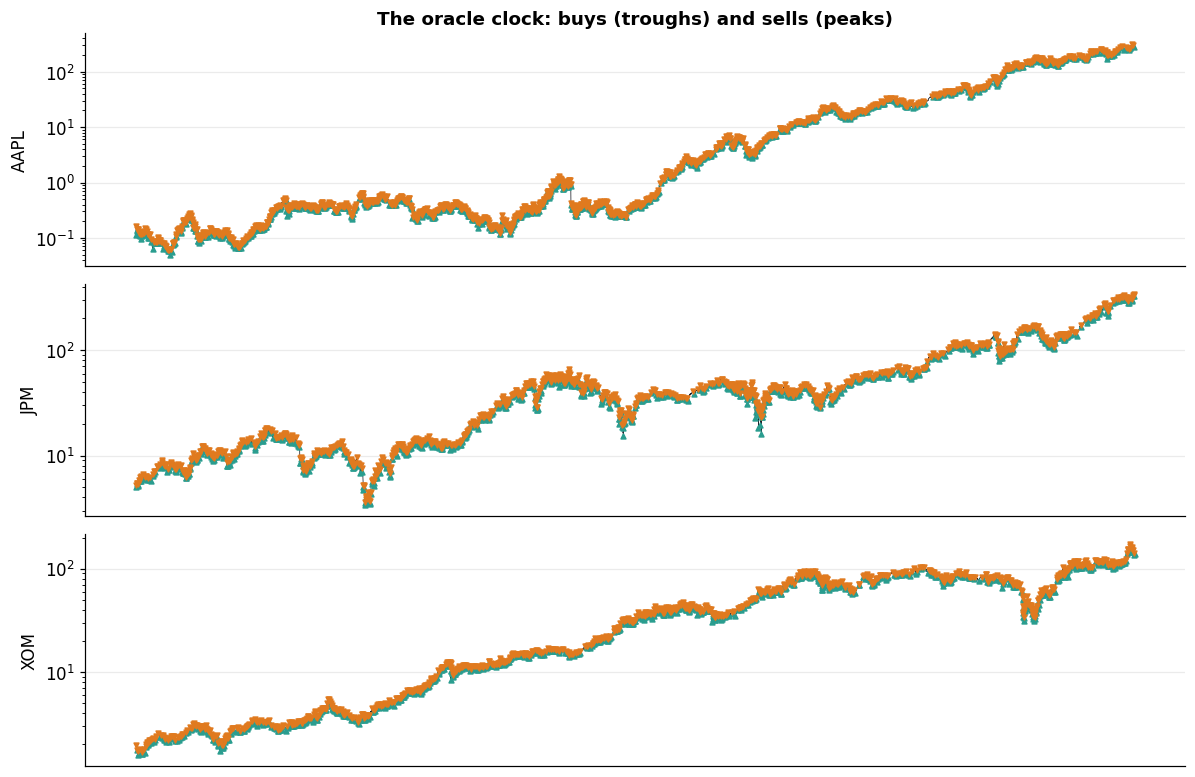

AAPL: 1245 buys, 1244 sells over 11486 days
JPM: 993 buys, 994 sells over 11674 days
XOM: 1012 buys, 1012 sells over 14252 days


In [3]:
from behaviour import buy_sell_occurrences
prices = {t: load_stock(t) for t in STOCKS}
clocks = {t: buy_sell_occurrences(prices[t], THETA) for t in STOCKS}   # (buys, sells)
fig, axes = plt.subplots(len(STOCKS), 1, figsize=(11, 2.4*len(STOCKS)))
for ax, t in zip(np.atleast_1d(axes), STOCKS):
    p = prices[t]; b, s = clocks[t]
    ax.plot(p, color=INK, lw=0.5)
    ax.scatter(b, [p[i] for i in b], marker="^", s=10, color=OK, zorder=3)
    ax.scatter(s, [p[i] for i in s], marker="v", s=10, color=BAD, zorder=3)
    ax.set_yscale("log"); ax.set_ylabel(t); ax.set_xticks([])
axes[0].set_title("The oracle clock: buys (troughs) and sells (peaks)")
plt.tight_layout(); plt.show()
for t in STOCKS:
    b, s = clocks[t]; print(f"{t}: {len(b)} buys, {len(s)} sells over {len(prices[t])} days")

### 1.2 — The behaviour table
Following the project's original method, we tabulate the buy pattern as an occurrence set:
the **ordinal**, the **position** (day), the **gap** to the previous turn, and the **ratio**
of consecutive gaps. For a deterministic gate this ratio column would be *constant* (an
exact self-similar law). Watch what the market does.

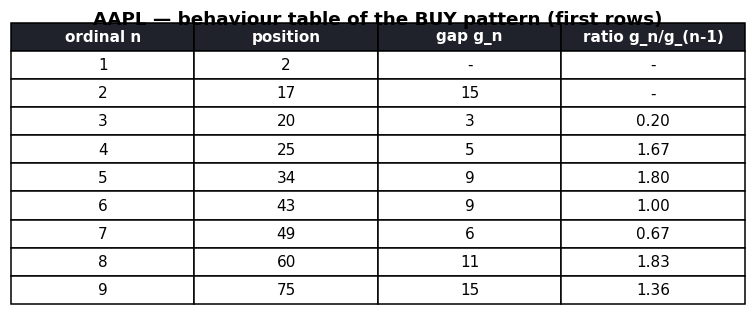

AAPL: ratio column scatter (cv of gaps) = 0.75  -> exact formula? False
JPM: ratio column scatter (cv of gaps) = 0.74  -> exact formula? False
XOM: ratio column scatter (cv of gaps) = 0.76  -> exact formula? False


In [4]:
from behaviour import behaviour_table, exact_formula_score
t0 = STOCKS[0]; buys0 = clocks[t0][0]
tbl = behaviour_table(buys0, 9)
rows = [[r["ordinal"], r["position"], "-" if r["gap"] is None else r["gap"],
         "-" if r["ratio"] is None else f"{r['ratio']:.2f}"] for r in tbl]
fig, ax = plt.subplots(figsize=(7, 3)); ax.axis("off")
tb = ax.table(cellText=rows, colLabels=["ordinal n","position","gap g_n","ratio g_n/g_(n-1)"],
              loc="center", cellLoc="center")
tb.auto_set_font_size(False); tb.set_fontsize(10); tb.scale(1, 1.5)
for (r_,c_),cell in tb.get_celld().items():
    if r_==0: cell.set_facecolor(INK); cell.set_text_props(color="white", fontweight="bold")
ax.set_title(f"{t0} — behaviour table of the BUY pattern (first rows)", fontweight="bold")
plt.tight_layout(); plt.show()
for t in STOCKS:
    sc = exact_formula_score(clocks[t][0])
    print(f"{t}: ratio column scatter (cv of gaps) = {sc['cv_gaps']:.2f}  -> exact formula? {sc['exact']}")

### 1.3 — The regularities we find (and the one we do not)
The ratio column **scatters** (cv ≈ 0.8, nowhere near constant): there is **no exact,
closed-form behaviour formula** — the market is not a deterministic gate. But three real
regularities *do* survive, and they are what the model is built from:

* **self-excitation** — turns arrive in **bursts** (one turn raises the chance of the next);
* **self-similarity** — that burstiness repeats across time-scales (a Fano exponent ≈ ½);
* **a heavy-tailed gap law** — the waiting times are lognormal, not clockwork.

Below: the burstiness (event raster) and the self-similarity (Fano exponent) for each stock.

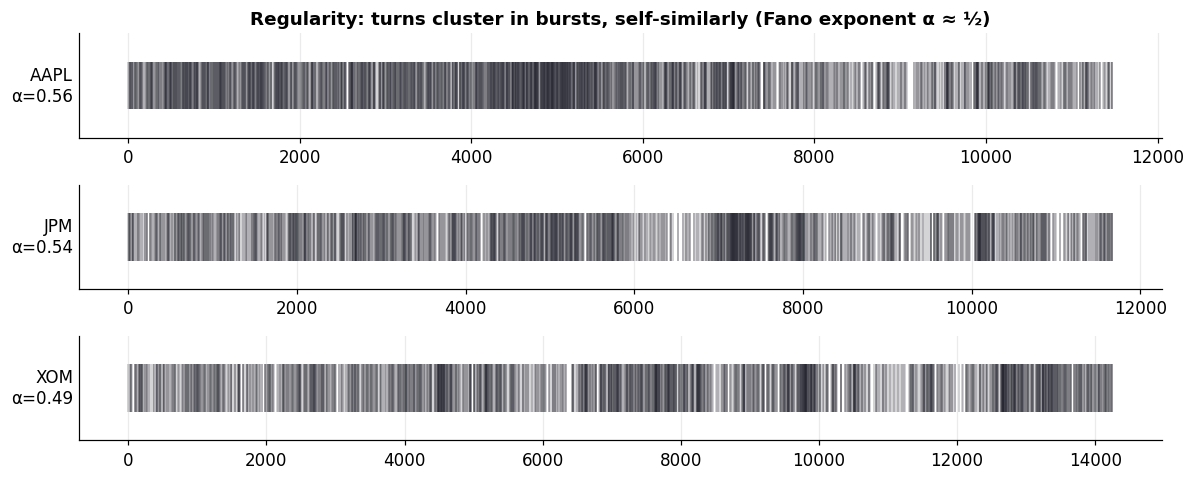

In [5]:
from point_process import fano_exponent
WIN = [10,20,40,80,160,320]
fig, axes = plt.subplots(len(STOCKS), 1, figsize=(11, 1.5*len(STOCKS)))
for ax, t in zip(np.atleast_1d(axes), STOCKS):
    b, s = clocks[t]; clock = sorted(b+s)
    ax.eventplot([clock], colors=[INK], lineoffsets=0, linelengths=0.8, linewidths=0.25)
    a = fano_exponent(clock, len(prices[t]), WIN)["alpha"]
    ax.set_yticks([]); ax.set_ylabel(f"{t}\nα={a:.2f}", rotation=0, ha="right", va="center")
axes[0].set_title("Regularity: turns cluster in bursts, self-similarly (Fano exponent α ≈ ½)")
plt.tight_layout(); plt.show()

### 1.4 — The behaviour formula, and what it *is*
From those regularities the model writes itself: a **self-exciting (Hawkes) law** with
**three numbers** — a baseline rate, an excitation size, a decay speed. That is the
behaviour formula. To be exact about what we have built:

* **A behaviour table?** No — the table's ratio column scatters; there is no exact tabulated law.
* **A behaviour formula?** **Yes** — but a *statistical* one (three numbers), not a closed-form
  index-set formula, because the market is not deterministic.
* **A complex network?** No — a deterministic Boolean network has an exact repertoire; the
  market does not. The three numbers are the honest, compressed generator of the *statistics*.

Here are the three models, one per stock.

In [6]:
from behaviour import hawkes_formula
models = {}
for t in STOCKS:
    T = float(len(prices[t]))
    fb = hawkes_formula(clocks[t][0], T); fs = hawkes_formula(clocks[t][1], T)
    models[t] = {"buy": fb, "sell": fs}
    print(f"{t}:  BUY formula  mu={fb['mu']:.4f}  alpha={fb['alpha']:.4f}  beta={fb['beta']:.4f}"
          f"  (branching n={fb['branching_ratio']:.2f}, memory {1/fb['beta']:.0f}d)")
print("\nThree numbers per pattern -- that is the whole model. It reproduces the STATISTICS")
print("of the clock (its burstiness and self-similarity), not the exact days.")

AAPL:  BUY formula  mu=0.0361  alpha=0.0031  beta=0.0046  (branching n=0.67, memory 218d)


JPM:  BUY formula  mu=0.0349  alpha=0.0034  beta=0.0058  (branching n=0.59, memory 172d)


XOM:  BUY formula  mu=0.0363  alpha=0.0022  beta=0.0046  (branching n=0.48, memory 218d)

Three numbers per pattern -- that is the whole model. It reproduces the STATISTICS
of the clock (its burstiness and self-similarity), not the exact days.


## Phase 2 · Predicting the clock vs the oracle

Now the test. Fit each model on the first 70% of history; on the held-out 30% let it fire
predicted turns on its highest-intensity days, and match them to the oracle's real turns —
requiring **precise timing (within ±2 days)**. We read off **precision** (of the calls made,
how many were real turns) and **recall** (of the real turns, how many we caught), against a
random predictor firing the same number of times.

In [7]:
from models import causal_intensity, fit_train
from predict import predicted_events, match_events
import statistics, random
rng = random.Random(7); TOL = 2
def predict_side(events, n):
    t_tr = int(n*0.7); train=[e for e in events if e<=t_tr]; test=[e for e in events if e>t_tr]
    f = fit_train(events, t_tr)
    lam = causal_intensity(events, n, f["mu"], f["alpha"], f["beta"])
    gaps=[train[i+1]-train[i] for i in range(len(train)-1)]; refr=max(2, statistics.median(gaps)//2)
    k = max(1, round(len(train)/t_tr*(n-t_tr)))
    pred = predicted_events(lam, t_tr+1, int(refr), k)
    return pred, test, match_events(pred, test, TOL)
print(f"{'stock':6}{'side':5}{'precision':>10}{'recall':>8}{'F1':>7}   (vs random ~0.37 F1)")
det = {}
for t in STOCKS:
    n = len(prices[t]); det[t] = {}
    for side, ev in (("buy", clocks[t][0]), ("sell", clocks[t][1])):
        pred, test, m = predict_side(ev, n); det[t][side] = (pred, test)
        print(f"{t:6}{side:5}{m['precision']:>10.3f}{m['recall']:>8.3f}{m['f1']:>7.3f}")

stock side  precision  recall     F1   (vs random ~0.37 F1)
AAPL  buy       0.313   0.524  0.392


AAPL  sell      0.315   0.530  0.395
JPM   buy       0.400   0.553  0.464


JPM   sell      0.400   0.551  0.463
XOM   buy       0.503   0.540  0.521
XOM   sell      0.474   0.509  0.491


And to *see* it: a slice of held-out time for one stock, the predicted buy days against the
real ones. Where the model fires, a real trough is often nearby — but not always.

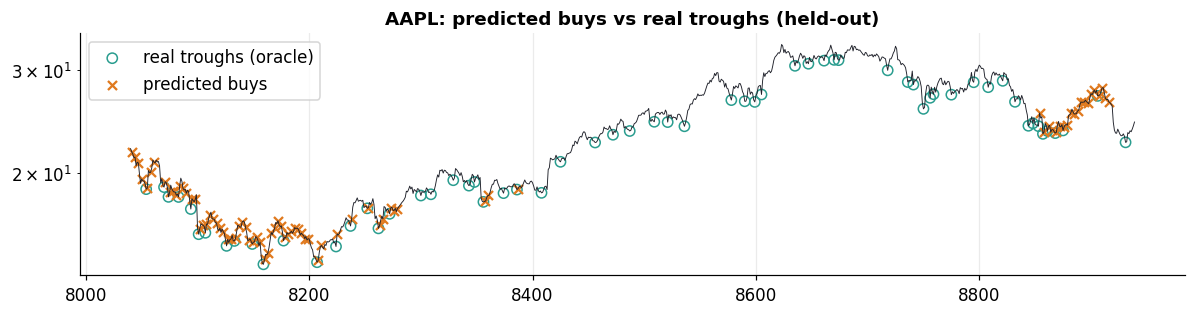

In [8]:
t = STOCKS[0]; pred, test = det[t]["buy"]; p = prices[t]; n=len(p); t_tr=int(n*0.7)
lo, hi = t_tr, min(n, t_tr+900)
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(range(lo,hi), p[lo:hi], color=INK, lw=0.6)
pb=[i for i in pred if lo<=i<hi]; ab=[i for i in test if lo<=i<hi]
ax.scatter(ab, [p[i] for i in ab], marker="o", s=45, facecolors="none", edgecolors=OK, label="real troughs (oracle)")
ax.scatter(pb, [p[i] for i in pb], marker="x", s=35, color=BAD, label="predicted buys")
ax.set_yscale("log"); ax.set_title(f"{t}: predicted buys vs real troughs (held-out)"); ax.legend()
plt.tight_layout(); plt.show()

## Phase 3 · How good are individual models, in general? (100 stocks)

Three stocks could be luck. Across all 100, we sweep the timing tolerance. At **precise**
tolerances the model beats a random predictor clearly; only at **loose** tolerances does
random win — because a wide window tiles the timeline and matches almost anything. The
honest reading: **the clock is predictable to within a couple of days**, modestly.

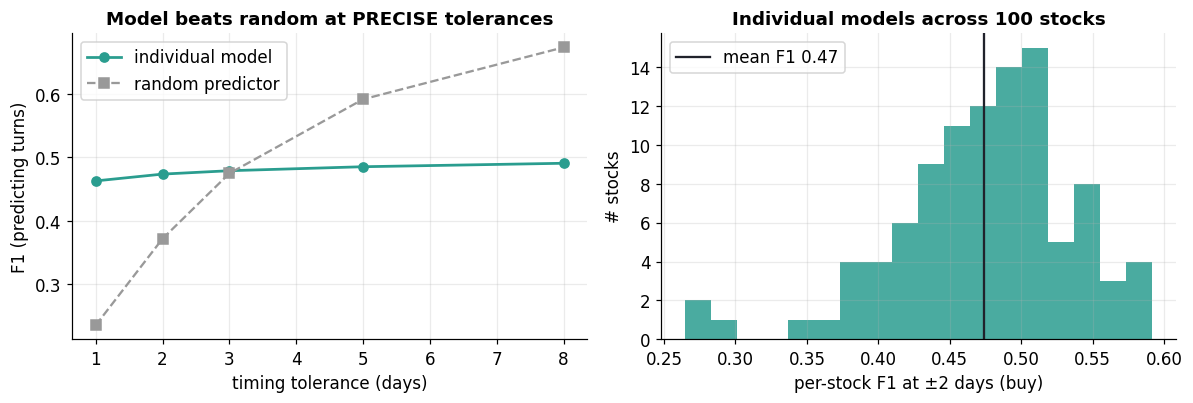

at +/-2 days: model precision 0.436, recall 0.529, F1 0.474  vs random F1 0.372. Real, modest: catches about
half the turns, roughly half its calls are right, and it beats chance at precise timing.


In [9]:
tols = RP["tols"]
mf = [RP["sweep_buy"][str(x)]["model_f1"] for x in tols]
rf = [RP["sweep_buy"][str(x)]["rand_f1"] for x in tols]
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 3.8))
ax.plot(tols, mf, marker="o", color=OK, lw=1.8, label="individual model")
ax.plot(tols, rf, marker="s", color="#999", lw=1.5, ls="--", label="random predictor")
ax.set_xlabel("timing tolerance (days)"); ax.set_ylabel("F1 (predicting turns)")
ax.set_title("Model beats random at PRECISE tolerances"); ax.legend()
f1b = [r["buy"]["f1"] for r in RP["rows"]]
bx.hist(f1b, bins=18, color=OK, alpha=0.85)
bx.axvline(np.mean(f1b), color=INK, lw=1.5, label=f"mean F1 {np.mean(f1b):.2f}")
bx.set_xlabel("per-stock F1 at ±2 days (buy)"); bx.set_ylabel("# stocks"); bx.legend()
bx.set_title("Individual models across 100 stocks")
plt.tight_layout(); plt.show()
print(f"at +/-2 days: model precision {RP['buy']['precision']:.3f}, recall {RP['buy']['recall']:.3f}, "
      f"F1 {RP['buy']['f1']:.3f}  vs random F1 {RP['buy']['rand_f1']:.3f}. Real, modest: catches about")
print("half the turns, roughly half its calls are right, and it beats chance at precise timing.")

## Phase 4 · Trading three examples with their own clock models

Finally the money. We let each stock's own clock models trade it, out of sample: **buy** on a
predicted trough, **sell** on a predicted peak, causally. For each stock we plot the price
with the executed moves, and the **accumulated profit** against buy-and-hold.

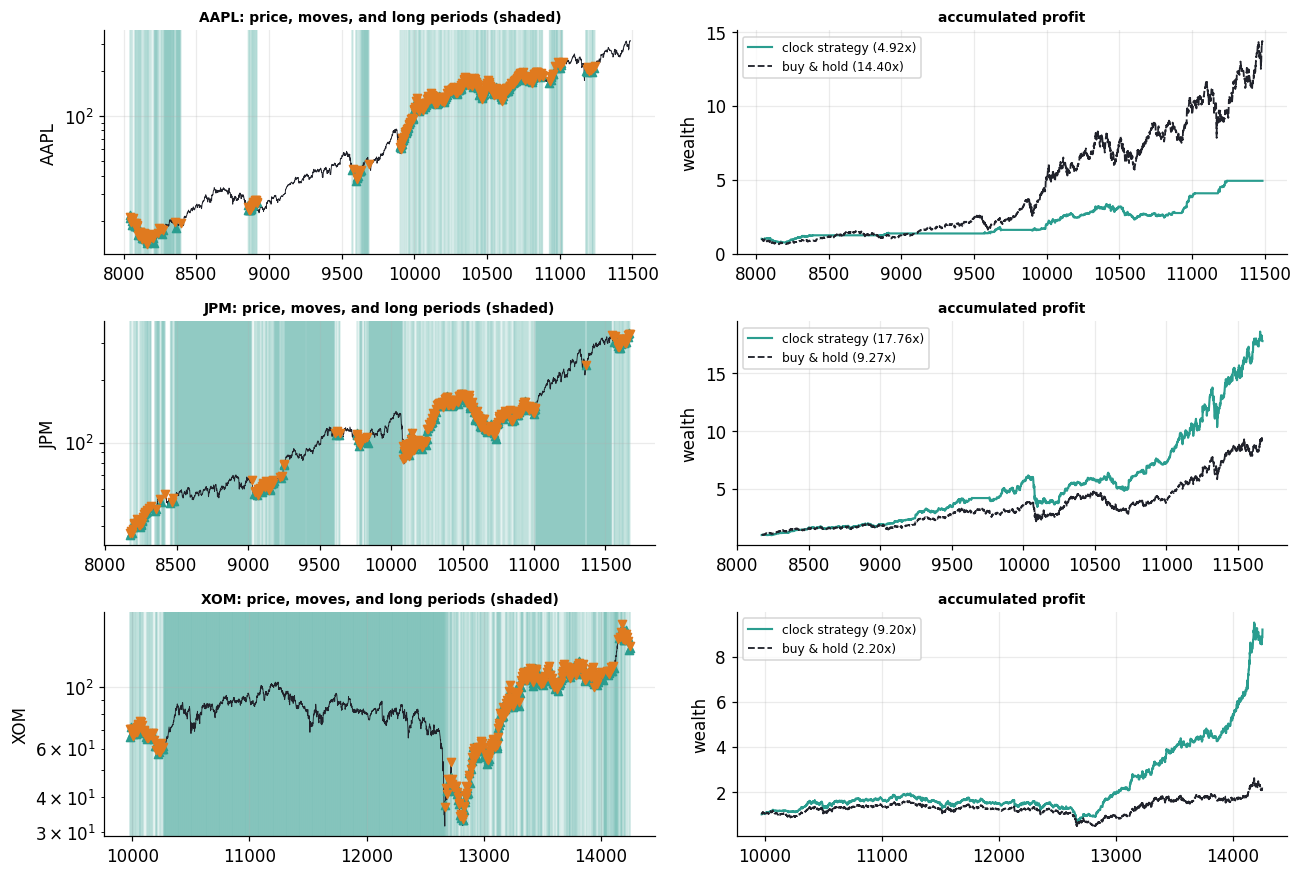

The strategy trades on real (weak) timing skill, but -- as the programme has shown --
it does not beat buy-and-hold: knowing WHEN a turn is near is not knowing the PRICE.


In [10]:
from predict import trade_sim
fig, axes = plt.subplots(len(STOCKS), 2, figsize=(12, 2.7*len(STOCKS)))
for row, t in zip(axes, STOCKS):
    p = prices[t]; n=len(p); t_tr=int(n*0.7)
    buy_pred = det[t]["buy"][0]; sell_pred = det[t]["sell"][0]
    sim = trade_sim(p, buy_pred, sell_pred, cost=0.0005, start=t_tr)
    xs = list(range(t_tr, n))
    ax0, ax1 = row
    ax0.plot(xs, p[t_tr:], color=INK, lw=0.6)
    ax0.scatter(sim["buys"], [p[i] for i in sim["buys"]], marker="^", s=28, color=OK, zorder=3)
    ax0.scatter(sim["sells"], [p[i] for i in sim["sells"]], marker="v", s=28, color=BAD, zorder=3)
    for i in range(len(xs)-1):
        if sim["positions"][i]: ax0.axvspan(xs[i], xs[i]+1, color=OK, alpha=0.05)
    ax0.set_yscale("log"); ax0.set_ylabel(t); ax0.set_title(f"{t}: price, moves, and long periods (shaded)", fontsize=9)
    ax1.plot(xs, sim["equity"], color=OK, lw=1.4, label=f"clock strategy ({sim['final']:.2f}x)")
    ax1.plot(xs, sim["buy_hold"], color=INK, lw=1.2, ls="--", label=f"buy & hold ({sim['bh_final']:.2f}x)")
    ax1.set_ylabel("wealth"); ax1.legend(fontsize=8); ax1.set_title("accumulated profit", fontsize=9)
plt.tight_layout(); plt.show()
print("The strategy trades on real (weak) timing skill, but -- as the programme has shown --")
print("it does not beat buy-and-hold: knowing WHEN a turn is near is not knowing the PRICE.")

## What we built, and what it is worth

* We built each model **from the data**: a behaviour table (whose ratio column scattered, so
  **no exact formula**), three surviving regularities (self-excitation, self-similarity, a
  lognormal gap law), and from them a **statistical behaviour formula** — three Hawkes
  numbers. Not a behaviour table, not a complex network: a compressed generator of the
  clock's *statistics*.
* It **predicts the clock** to within a couple of days, modestly better than chance
  (F1 ≈ 0.47 at ±2 days, precision ≈ 0.44, recall ≈ 0.53), on 100 stocks.
* It **does not make money**: trading its signals does not beat buy-and-hold, because timing
  is not price. The clock is a genuine, compressible scientific object — and a weak trading
  signal. Both are shown, neither is hidden.

*Reproduce:* `python level18/exp41_clock_prediction.py` writes the 100-stock JSON this
notebook reads; `python notebooks/build_14.py` rebuilds the notebook.